In [25]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
# Change DATASET to one of:
#   "DL_similarity"   →  BPIC_test_DL_similarity.csv
#   "MAE_rrt"         →  BPIC_test_MAE_rrt_minutes.csv
#   "MAE_ttne"        →  BPIC_test_MAE_ttne_minutes.csv

DATA = "BPICDA"
TARGET = "DL"
CAPPED = False

# Target column name matches the file suffix
TARGET_COLS = {
    "DL": "test_DL_similarity",
    "rrt": "test_MAE_rrt_minutes",
    "ttne": "test_MAE_ttne_minutes",
}

# Hyperparameter columns (same in all three files)
FEATURE_COLS = ["d_model", "d_ff_multiplier", "num_layers",
                "learning_rate", "dropout", "weight_decay"]

# Columns to log-transform (span multiple orders of magnitude)
LOG_COLS = ["learning_rate", "weight_decay"]

N_TREES = 48
RANDOM_STATE = 42
# ──────────────────────────────────────────────────────────────────────────────
print(f"Active dataset : {DATA}")
print(f"Target column  : {TARGET_COLS[TARGET]}")

Active dataset : BPICDA
Target column  : test_DL_similarity


In [26]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor


# ── Load data ────────────────────────────────────────────────────────────────
if CAPPED == True:
    df = pd.read_csv(f"{DATA}_{TARGET}_capped.csv")
else:
    df = pd.read_csv(f"{DATA}_{TARGET}.csv")
    
target_col = TARGET_COLS[TARGET]

X = df[FEATURE_COLS].copy()
y = df[target_col].copy()

print(f"Samples: {len(df)}   Features: {X.shape[1]}   Target: {target_col}")
print(f"\nFeature ranges:")
print(X.agg(["min", "max"]).T.to_string())


Samples: 100   Features: 6   Target: test_DL_similarity

Feature ranges:
                      min        max
d_model          8.000000  96.000000
d_ff_multiplier  2.000000   8.000000
num_layers       2.000000   8.000000
learning_rate    0.000010   0.009808
dropout          0.006696   0.695759
weight_decay     0.000011   0.009418


In [27]:
from fanova import fANOVA
import os
import itertools
import ConfigSpace
from ConfigSpace.hyperparameters import UniformFloatHyperparameter
from fanova.visualizer import Visualizer

cs = ConfigSpace.ConfigurationSpace()
for col in FEATURE_COLS:
    cs.add_hyperparameter(
        UniformFloatHyperparameter(
            col,
            float(X[col].min()),
            float(X[col].max()),
            log=(col in LOG_COLS)   # ← log-spaced grid for learning_rate & weight_decay
        )
    )

# fit fANOVA with the named ConfigSpace
cs_param_order = [hp.name for hp in cs.get_hyperparameters()]

# Reorder X to match
X_cs = X[cs_param_order]

f_named = fANOVA(X_cs.astype(np.float64), y.values.astype(np.float64),
                 config_space=cs,
                 n_trees=N_TREES, seed=RANDOM_STATE, min_samples_leaf=3)

results = {}
for i, col in enumerate(cs_param_order):
    imp = f_named.quantify_importance((i,))
    results[col] = imp[(i,)]["individual importance"]

fanova_importance = pd.Series(results).sort_values(ascending=False)

print("=== fANOVA: Main effects ===")
print(f"\nFraction of variance explained per hyperparameter:")
print(fanova_importance.to_string())
print(f"\nTotal explained by main effects: {fanova_importance.sum():.4f}")

=== fANOVA: Main effects ===

Fraction of variance explained per hyperparameter:
learning_rate      0.575247
d_ff_multiplier    0.069648
d_model            0.067156
dropout            0.048268
num_layers         0.033704
weight_decay       0.015957

Total explained by main effects: 0.8100


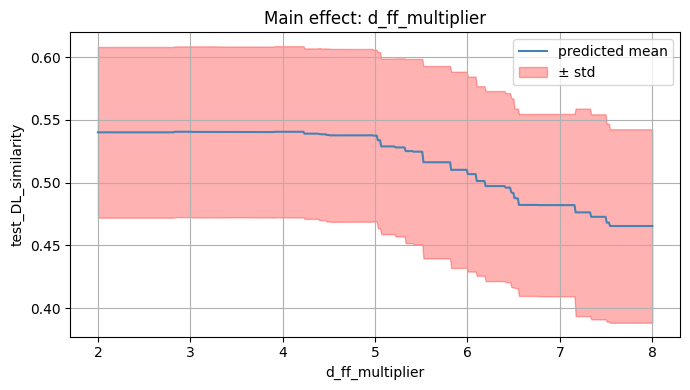

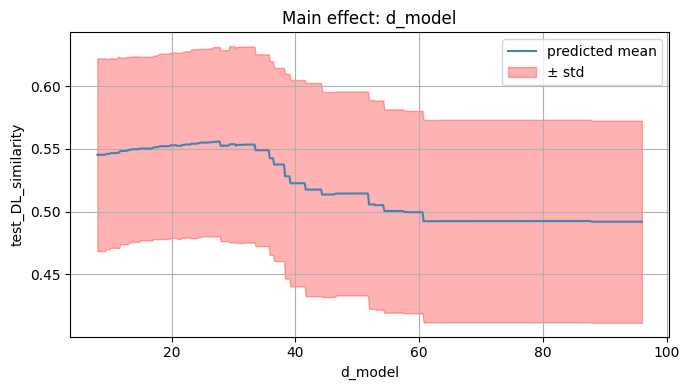

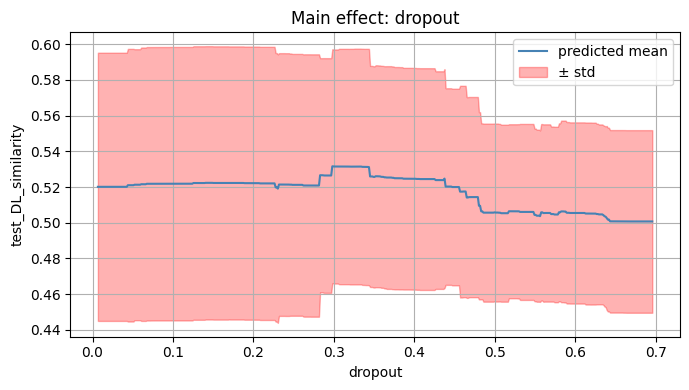

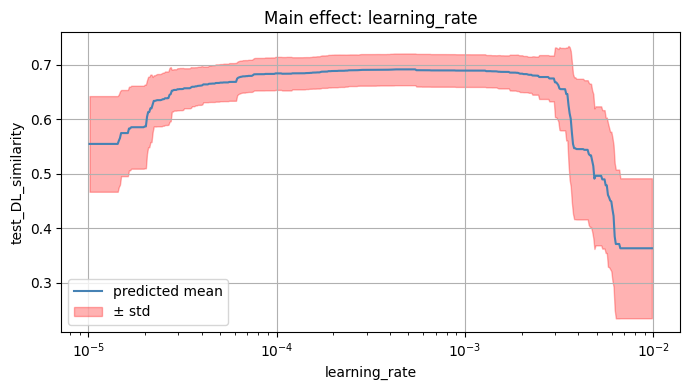

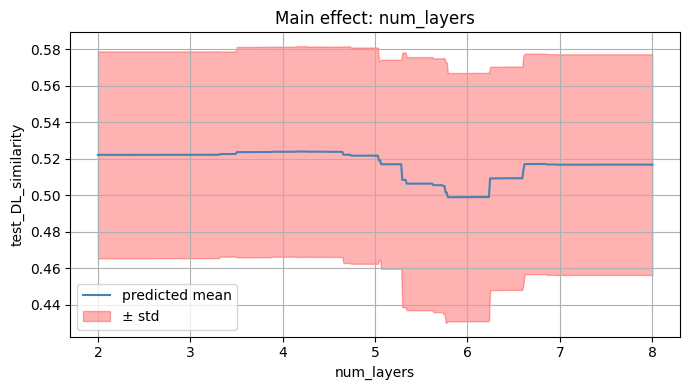

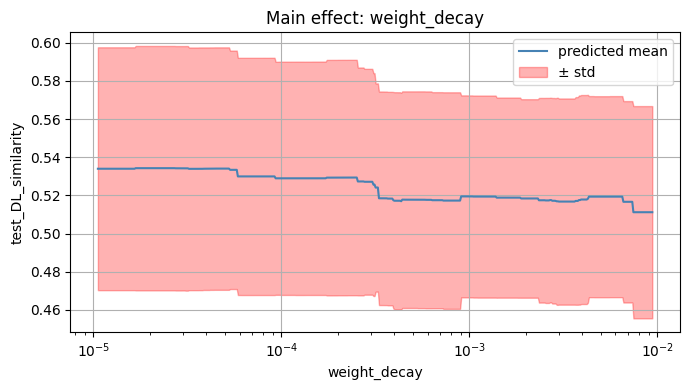

In [28]:
# ── fANOVA: 1D main effect plots ─────────────────────────────────────────────
import matplotlib.pyplot as plt

plot_dir = "fanova_plots"
os.makedirs(plot_dir, exist_ok=True)
vis = Visualizer(f_named, cs, plot_dir, y_label=target_col)

for i, col in enumerate(cs_param_order):
    mean, std, grid = vis.generate_marginal(i, resolution=500)
    mean = np.asarray(mean)
    std  = np.asarray(std)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(grid, mean, color='steelblue', label='predicted mean')
    ax.fill_between(grid, mean - std, mean + std, alpha=0.3, color='red', label='± std')
    if col in LOG_COLS:
        ax.set_xscale('log')
    ax.set_xlabel(col)
    ax.set_ylabel(target_col)
    ax.set_title(f"Main effect: {col}")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

In [29]:
# ── fANOVA: Pairwise interaction effect scores ────────────────────────────────
interaction_results = {}
for i, j in itertools.combinations(range(len(cs_param_order)), 2):
    p1, p2 = cs_param_order[i], cs_param_order[j]
    imp = f_named.quantify_importance((i, j))
    interaction_results[(p1, p2)] = imp[(i, j)]["individual importance"]

interaction_importance = (
    pd.Series(interaction_results)
    .rename_axis(["HP1", "HP2"])
    .sort_values(ascending=False)
)

print("=== fANOVA: Pairwise interaction effects ===")
print(f"\nFraction of variance explained per pair:")
print(interaction_importance.to_string())
print(f"\nTotal explained by pairwise interactions: {interaction_importance.sum():.4f}")

=== fANOVA: Pairwise interaction effects ===

Fraction of variance explained per pair:
HP1              HP2          
d_ff_multiplier  learning_rate    0.052094
d_model          learning_rate    0.052060
dropout          learning_rate    0.025380
d_ff_multiplier  num_layers       0.019587
dropout          num_layers       0.007007
learning_rate    num_layers       0.006155
                 weight_decay     0.005345
d_ff_multiplier  d_model          0.004107
d_model          num_layers       0.002458
dropout          weight_decay     0.002212
d_ff_multiplier  dropout          0.001575
d_model          dropout          0.001016
d_ff_multiplier  weight_decay     0.000872
num_layers       weight_decay     0.000350
d_model          weight_decay     0.000119

Total explained by pairwise interactions: 0.1803


Plotting: d_ff_multiplier × d_model


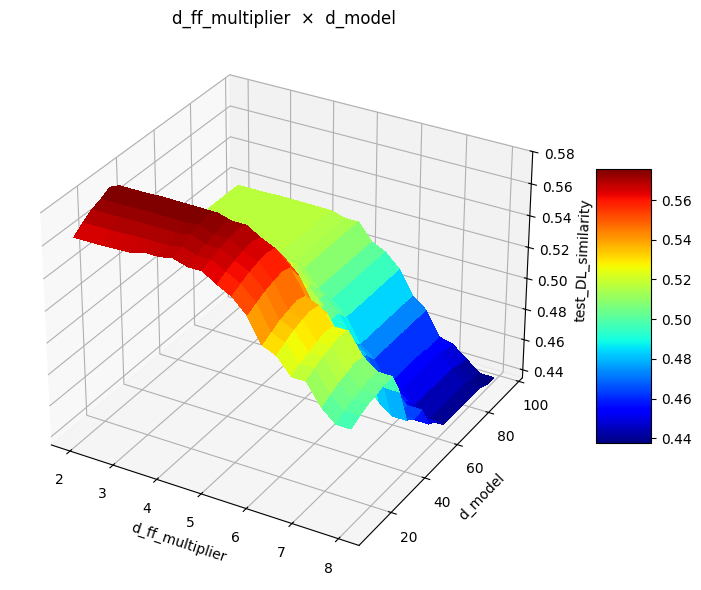

Plotting: d_ff_multiplier × dropout


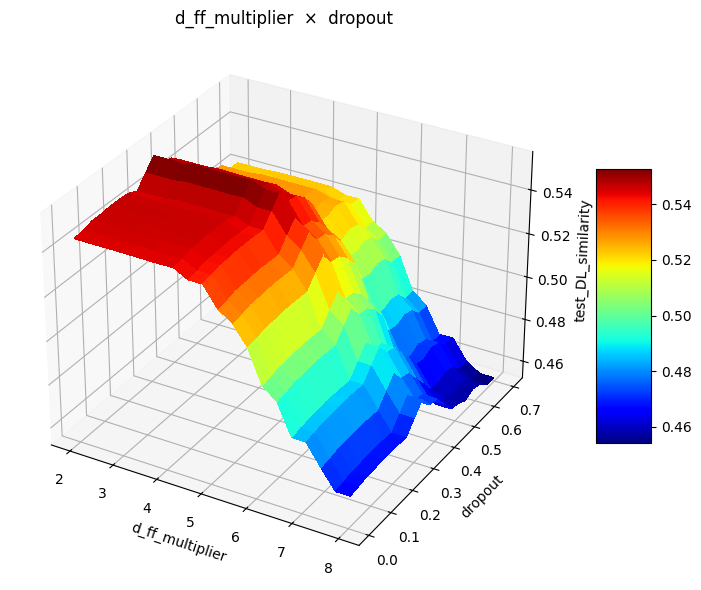

Plotting: d_ff_multiplier × learning_rate


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


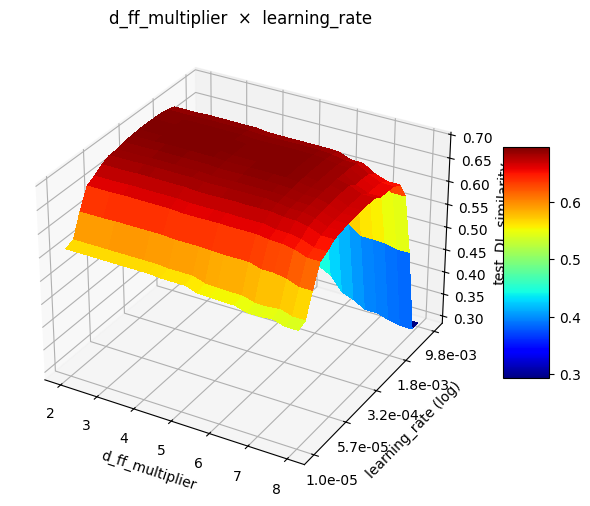

Plotting: d_ff_multiplier × num_layers


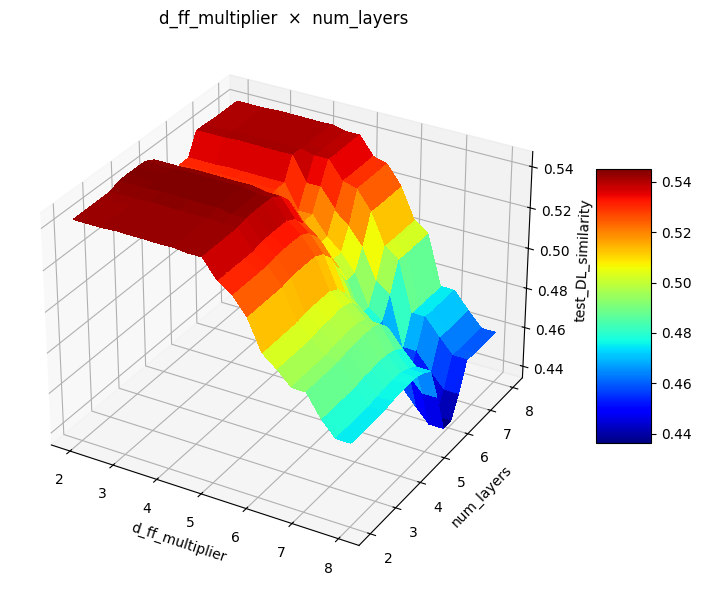

Plotting: d_ff_multiplier × weight_decay


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


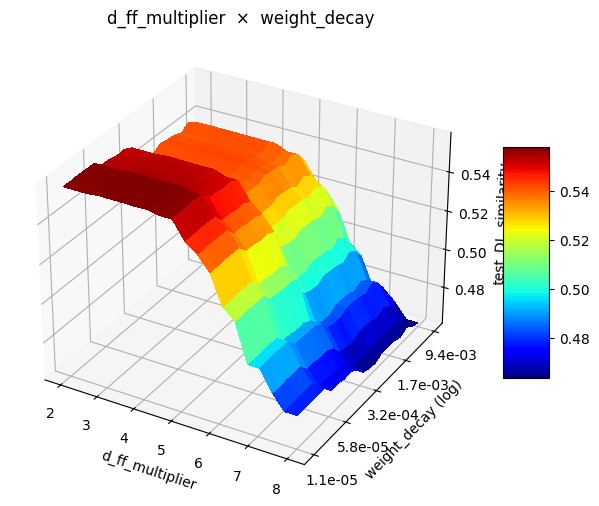

Plotting: d_model × dropout


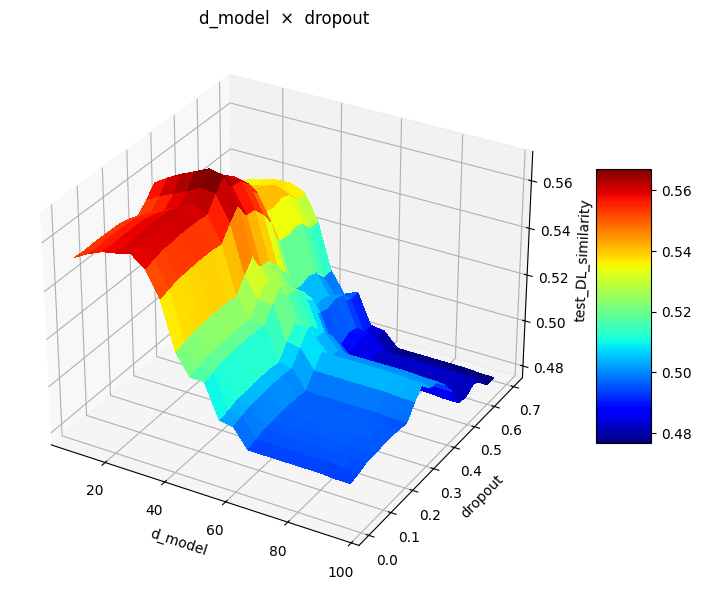

Plotting: d_model × learning_rate


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


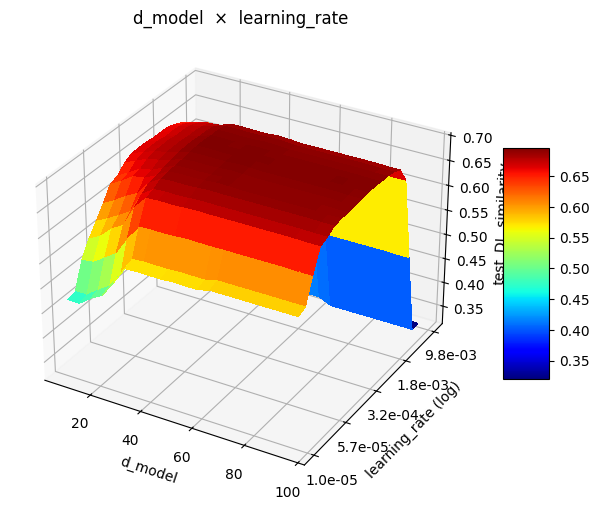

Plotting: d_model × num_layers


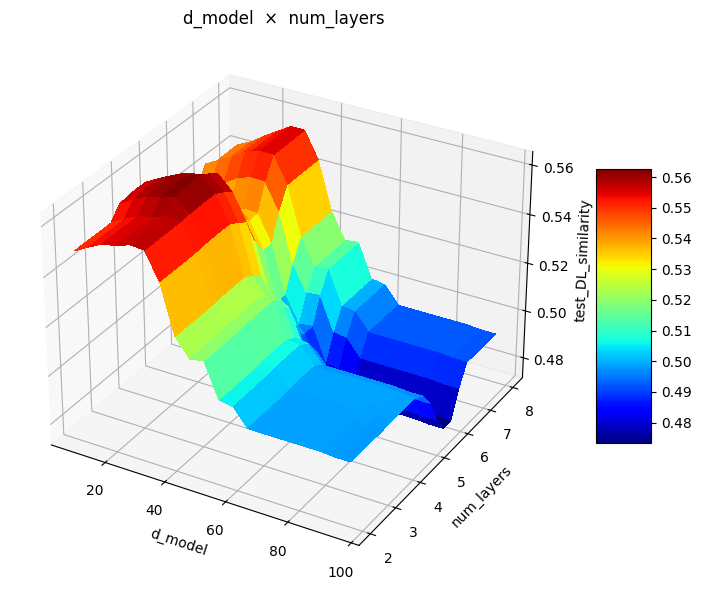

Plotting: d_model × weight_decay


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


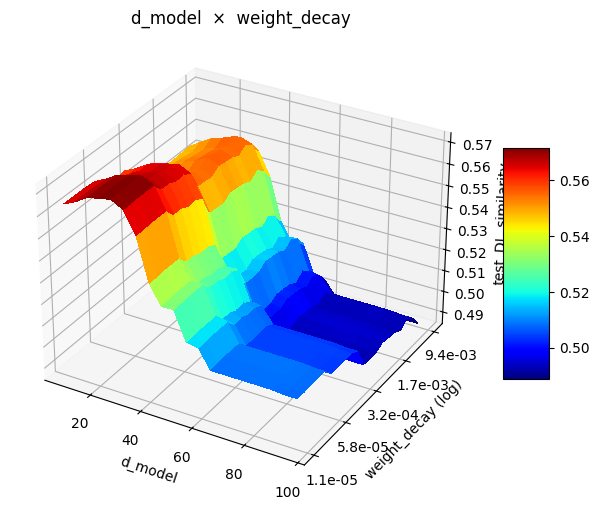

Plotting: dropout × learning_rate


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


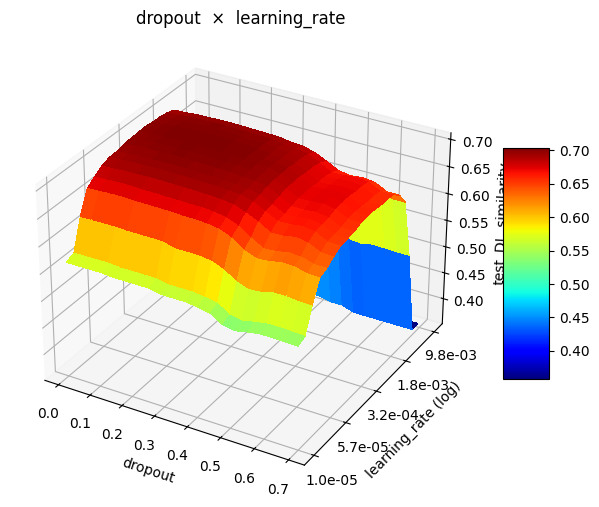

Plotting: dropout × num_layers


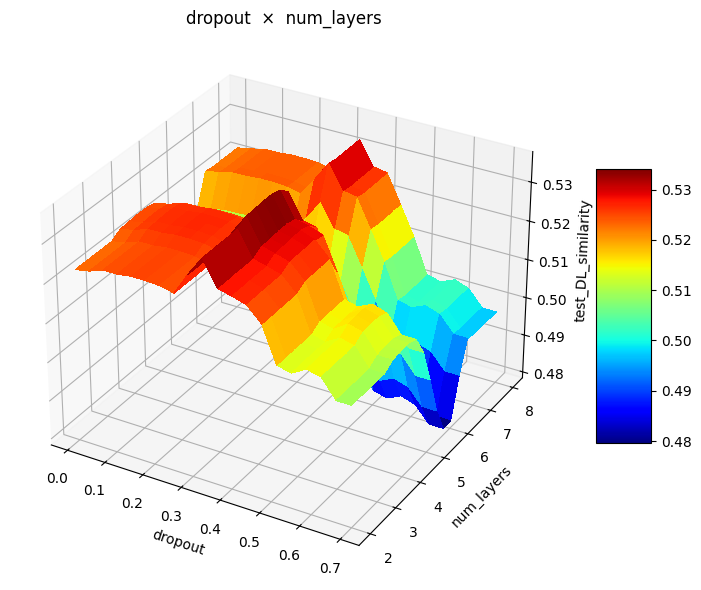

Plotting: dropout × weight_decay


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


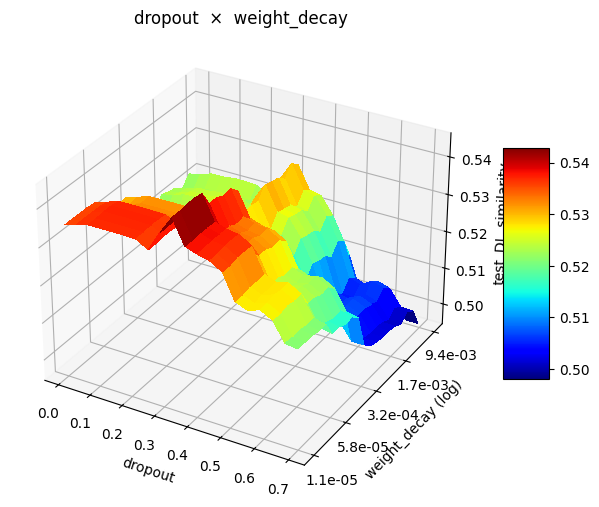

Plotting: learning_rate × num_layers


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


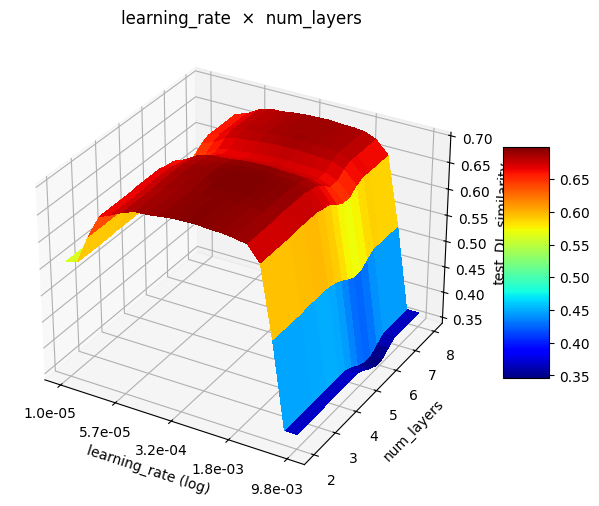

Plotting: learning_rate × weight_decay


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


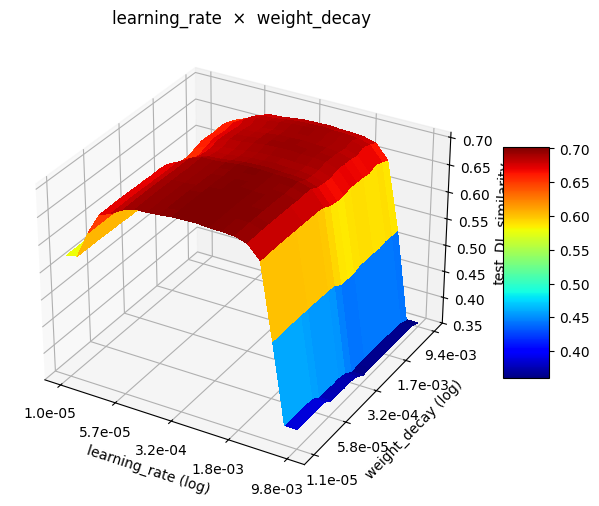

Plotting: num_layers × weight_decay


/var/folders/yk/b_tmk_vs63x7l6pmt80xdcnh0000gn/T/ipykernel_45826/1499697168.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


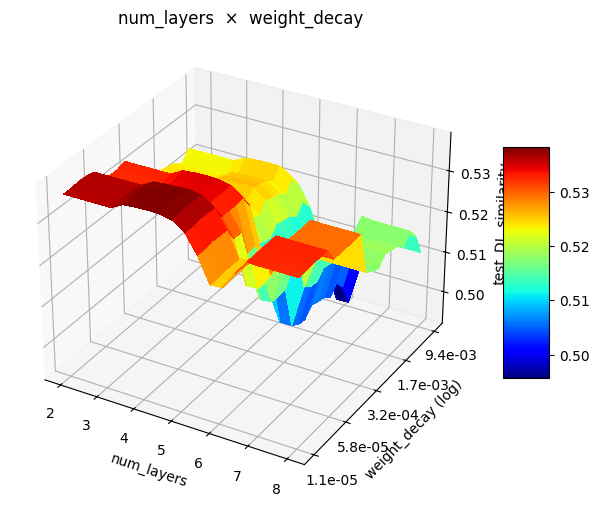

In [30]:
# ── fANOVA: 3D pairwise interaction plots ────────────────────────────────────
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

plot_dir = "fanova_plots"
os.makedirs(plot_dir, exist_ok=True)

vis = Visualizer(f_named, cs, plot_dir, y_label=target_col)

pairs = list(itertools.combinations(range(len(cs_param_order)), 2))
for i, j in pairs:
    p1, p2 = cs_param_order[i], cs_param_order[j]
    print(f"Plotting: {p1} × {p2}")

    grid_orig, zz = vis.generate_pairwise_marginal([i, j], resolution=20)

    # Transform axes that span orders of magnitude to log10 space
    g0 = np.log10(grid_orig[0]) if p1 in LOG_COLS else grid_orig[0]
    g1 = np.log10(grid_orig[1]) if p2 in LOG_COLS else grid_orig[1]
    xx, yy = np.meshgrid(g0, g1)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(xx, yy, zz.T, cmap='jet', linewidth=0, antialiased=False)

    # Restore human-readable tick labels on log-transformed axes
    if p1 in LOG_COLS:
        tick_vals = np.logspace(np.log10(grid_orig[0].min()), np.log10(grid_orig[0].max()), 5)
        ax.set_xticks(np.log10(tick_vals))
        ax.set_xticklabels([f"{v:.1e}" for v in tick_vals])
    if p2 in LOG_COLS:
        tick_vals = np.logspace(np.log10(grid_orig[1].min()), np.log10(grid_orig[1].max()), 5)
        ax.set_yticks(np.log10(tick_vals))
        ax.set_yticklabels([f"{v:.1e}" for v in tick_vals])

    ax.set_xlabel(p1 + (" (log)" if p1 in LOG_COLS else ""))
    ax.set_ylabel(p2 + (" (log)" if p2 in LOG_COLS else ""))
    ax.set_zlabel(target_col)
    ax.set_title(f"{p1}  ×  {p2}")
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.tight_layout()
    plt.show()

In [31]:
import plotly.graph_objects as go

# ── Choose your two hyperparameters ──────────────────────────────────────────
HP1 = "learning_rate"
HP2 = "d_model"
# ─────────────────────────────────────────────────────────────────────────────

i = cs_param_order.index(HP1)
j = cs_param_order.index(HP2)

grid_orig, zz = vis.generate_pairwise_marginal([i, j], resolution=20)

g0 = np.log10(grid_orig[0]) if HP1 in LOG_COLS else grid_orig[0]
g1 = np.log10(grid_orig[1]) if HP2 in LOG_COLS else grid_orig[1]

fig = go.Figure(data=[go.Surface(
    x=g0, y=g1, z=zz.T,
    colorscale='Jet'
)])
fig.update_layout(
    title=f"{HP1} × {HP2}",
    scene=dict(
        xaxis_title=HP1 + (" (log)" if HP1 in LOG_COLS else ""),
        yaxis_title=HP2 + (" (log)" if HP2 in LOG_COLS else ""),
        zaxis_title=target_col,
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.4))
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)
fig.show()